# Landsat Explorer

Welcome to the Landsat Explorer notebook. This notebook will introduce you to the different capabilities of Imagery Layers and how to use them when exploring Landsat imagery. This notebook style tutorial will take approximately 20 minutes. You can study any location of interest while using the tutorial.

## Landsat imagery

ArcGIS Online provides multispectral landsat imagery layer, that we'll be using for this tutorial. Let's connect to ArcGIS Online and query for the "Landsat Multispectral" imagery layer:

In [1]:
from arcgis.gis import GIS

In [2]:
# gis = GIS()
gis = GIS('https://geosaurus.maps.arcgis.com/', 'rsingh_geosaurus', 'P@ssw0rd@123')

In [3]:
landsat_item = gis.content.search('"Landsat Multispectral"', 'Imagery Layer', outside_org=True)[0]

<Item title:"Multispectral Landsat" type:Image Service owner:esri>
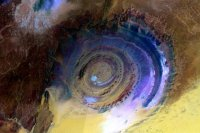

In [4]:
landsat_item

## Description

In [5]:
from IPython.display import HTML
HTML(landsat_item.description)

Band Num.


This imagery layer item contains the imagery layer that we'll be using for this tutorial. Let's save a reference to the layer in the landsat variable:

In [6]:
landsat_item.layers[0]

<ImageryLayer url:"https://landsat2.arcgis.com/arcgis/rest/services/Landsat/MS/ImageServer">

In [7]:
landsat = landsat_item.layers[0]

## Information on bands

In [8]:
import pandas as pd

In [9]:
pd.DataFrame(landsat.key_properties()['BandProperties'])

,BandIndex,BandName,DatasetTag,WavelengthMax,WavelengthMin
0,0,CoastalAerosol,MS,450,430
1,1,Blue,MS,510,450
2,2,Green,MS,590,530
3,3,Red,MS,670,640
4,4,NearInfrared,MS,880,850
5,5,ShortWaveInfrared_1,MS,1650,1570
6,6,ShortWaveInfrared_2,MS,2290,2110
7,7,Cirrus,MS,1380,1360


## Visualize the layer in the map widget
Let's visualize the layer by creating a map widget around our area of interest and adding the Landsat Imagery layer to it:

In [10]:
m = gis.map('Redlands, CA')
m

In [11]:
m.add_layer(landsat)

## Renderers

The multispectral imagery layer can be rendered using several different raster function chains (also known as raster function templates).

Each raster function chain incorporates different satellite bands to highlight different land cover features.

Obtain list of predefined raster function templates defined by the service backing the imagery layer:

In [12]:
landsat.properties

{
  "copyrightText": "",
  "pixelSizeX": 30,
  "allowedMosaicMethods": "ByAttribute,NorthWest,Center,LockRaster,Nadir,None",
  "supportsStatistics": true,
  "hasColormap": false,
  "maxImageHeight": 2000,
  "hasHistograms": false,
  "maxValues": [
    55000,
    55000,
    55000,
    55000,
    55000,
    55000,
    55000,
    55000
  ],
  "stdvValues": [
    3750,
    3750,
    3750,
    3750,
    3750,
    3750,
    3750,
    3750
  ],
  "initialExtent": {
    "xmax": 20037512.9328,
    "spatialReference": {
      "wkid": 102100,
      "latestWkid": 3857
    },
    "xmin": -20037507.0672,
    "ymin": -9694139.692100003,
    "ymax": 9698850.307899997
  },
  "maxImageWidth": 2000,
  "extent": {
    "xmax": 20037512.9328,
    "spatialReference": {
      "wkid": 102100,
      "latestWkid": 3857
    },
    "xmin": -20037507.0672,
    "ymin": -9694139.692100003,
    "ymax": 9698850.307899997
  },
  "objectIdField": "OBJECTID",
  "spatialReference": {
    "wkid": 102100,
    "latestWkid": 3

In [13]:
for rasterfunc in landsat.properties.rasterFunctionInfos:
    print(rasterfunc.name)

Agriculture with DRA
Bathymetric with DRA
Color Infrared with DRA
Geology with DRA
Natural Color with DRA
Short-wave Infrared with DRA
Agriculture
Bathymetric
Color Infrared
Geology
Natural Color
Short-wave Infrared
NDVI Colorized
Normalized Difference Moisture Index Colorized
NDVI Raw
NBR Raw
None


Let's apply the 'Color Infrared with DRA' raster function to visualize the color infrared view:

In [14]:
from arcgis.raster.functions import *

In [15]:
color_infrared = apply(landsat, 'Color Infrared with DRA')

In [16]:
m = gis.map('Redlands, CA')
m.add_layer(color_infrared)
m

A **true-color image** uses red, green and blue satellite bands to create an image that looks like a photograph. 

The **color infrared** view, on the other hand, uses the near infrared, red and green satellite bands to create an image. As a result, vegetation appears bright red in the image above.

## Exporting Images from Imagery Layer

In addition to visualizing the imagery layer in a map widget in the Jupyter Notebook, the imagery can be exported using the `export_image` method provided by ImageryLayers:

In [17]:
from IPython.display import Image

In [18]:
from arcgis.geocoding import geocode
area = geocode('Redlands, CA', out_sr=landsat.properties.spatialReference)[0]

In [19]:
img = landsat.export_image(bbox=area['extent'], size=[1200,450], f='image')

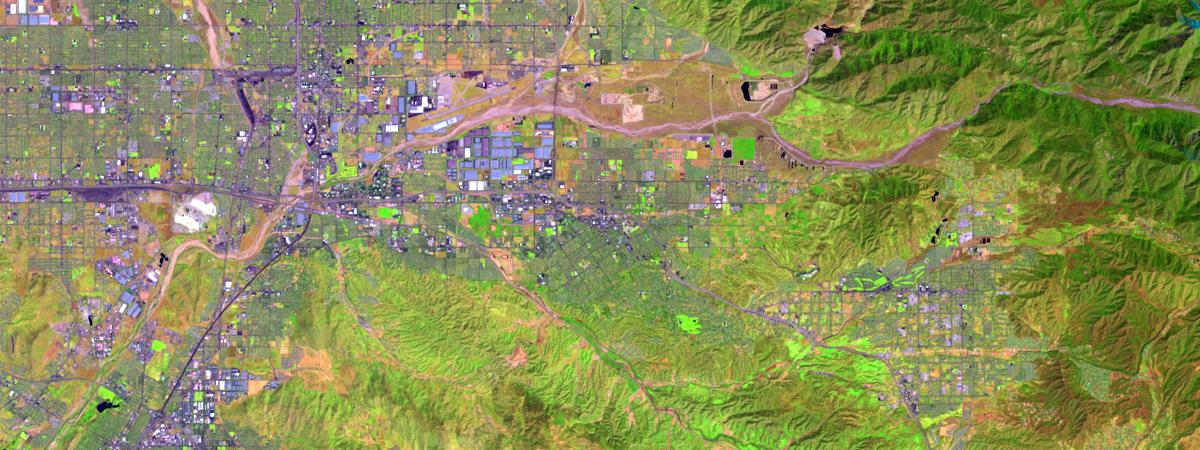

In [20]:
Image(img)

The exported image can be saved to a file by specifying a folder and file name:

In [21]:
savedimg = landsat.export_image(bbox=area['extent'], size=[1200,450], f='image', save_folder='.', save_file='img.jpg')

In [22]:
savedimg

'.\\img.jpg'

In [23]:
from IPython.display import Image

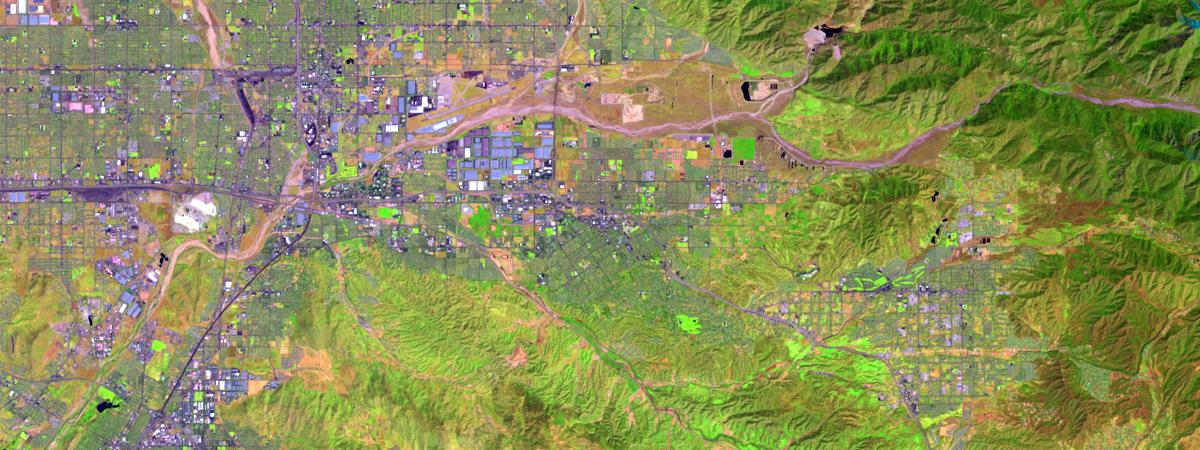

In [24]:
Image(filename=savedimg, width=1200, height=450)

### Exporting images an imagery layer to which a raster function chain has been applied

In [25]:
color_infrared = apply(landsat, 'Color Infrared with DRA')

In [26]:
img = color_infrared.export_image(bbox=area['extent'], size=[1200, 450], f='image')

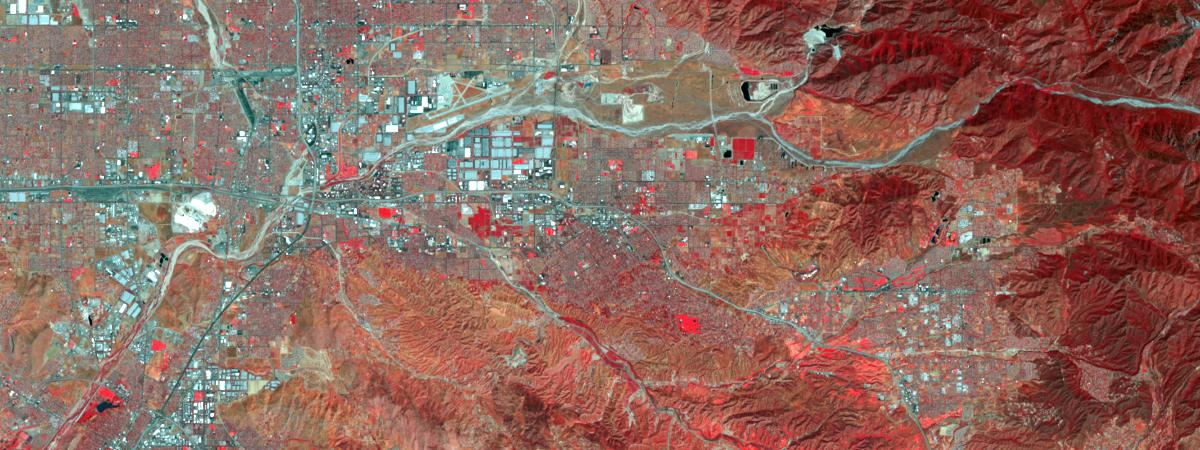

In [27]:
Image(img)

## Vegetation Index

An index combines two or more wavelengths to indicate the relative abundance of different land cover features, like vegetation or moisture.

Let's use the 'NDVI Colorized' raster function to visualize healthy, green vegetation:

In [28]:
ndvi_colorized = apply(landsat, 'NDVI Colorized')
img = ndvi_colorized.export_image(bbox=area['extent'], size=[1200, 450], f='image')

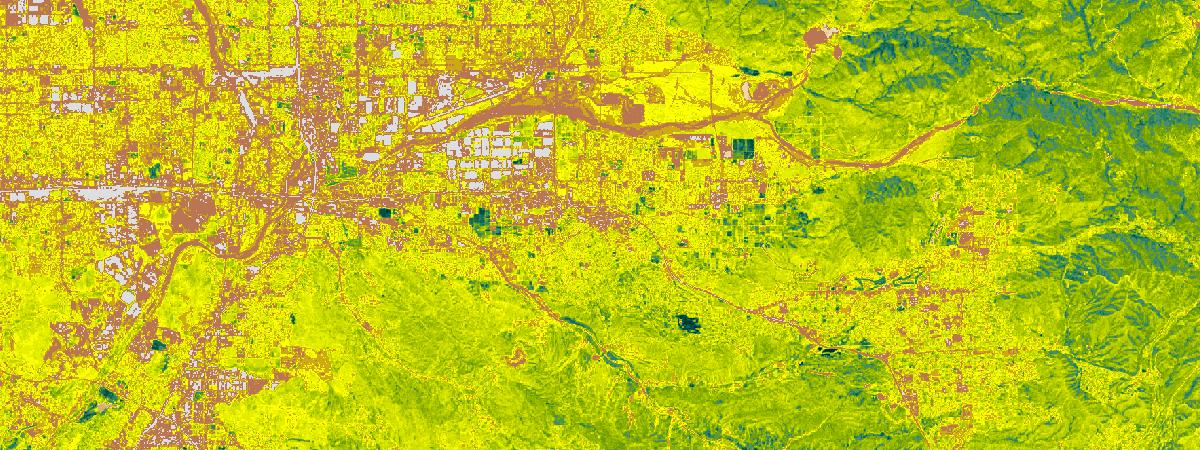

In [29]:
Image(img)

NDVI is an index that indicates the presence of healthy, green vegetation (seen in green above).

## Custom Bands

You can also create your own indexes and band combinations, as well as specify stretch and gamma values to adjust the image contrast.

The code below first extracts the [3 (Red), 2 (Green), 1 (Blue)] bands using the `extract_bands` function and passes it's output to the `stretch` function to enhance the image:

In [30]:
naturalcolor = stretch(extract_band(landsat, [3,2,1]), 
                    stretch_type='percentclip', min_percent=0.1, max_percent=0.1, gamma=[1, 1, 1], dra=True)

In [31]:
from arcgis.raster.analytics import generate_raster

In [32]:
img = naturalcolor.export_image(bbox=area['extent'], size=[1200, 450],  f='image')

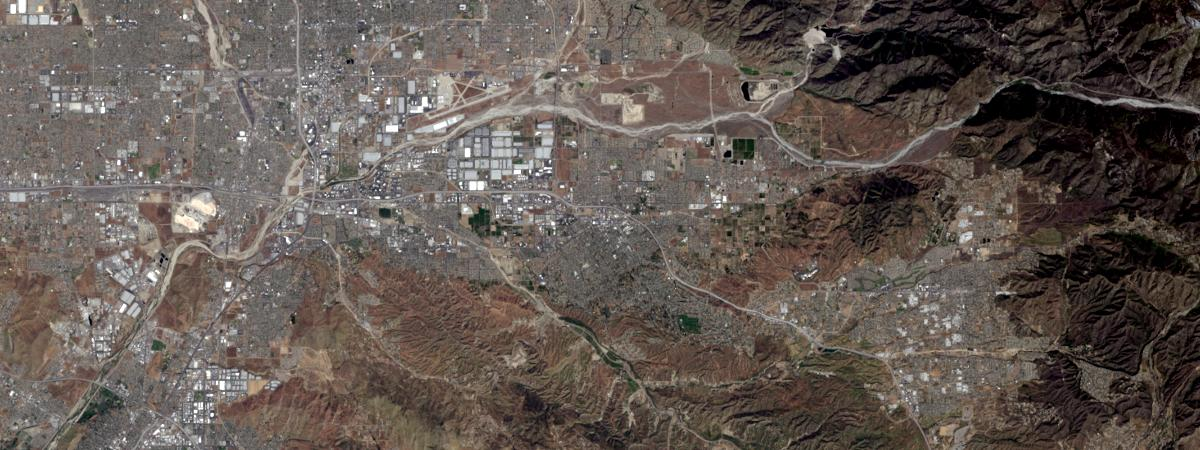

In [33]:
Image(img)

This is a true-color image (similar to a photograph), created using the red, green, and blue satellite bands. Notice how much easier it was to find healthy vegetation using the NDVI vegetation index, compared to the true-color image here.

# Image Attributes

The `get_samples()` method returns pixel values of the source data (i.e before any rendering rules or raster functions are applied) for a given geometry as well as image attributes, like Scene ID, Acquisition Date, and Cloud Cover.

In [34]:
g = arcgis.geometry.Geometry(area['extent'])

In [35]:
samples = landsat.get_samples(g, sample_count=50,
                                 out_fields='AcquisitionDate,OBJECTID,GroupName,Category,SunAzimuth,SunElevation,CloudCover')

In [36]:
samples[0]

{'attributes': {'AcquisitionDate': 1492280496321,
  'Category': 1,
  'CloudCover': 0.005,
  'GroupName': 'LC80400362017105LGN00_MTL',
  'OBJECTID': 478593,
  'SunAzimuth': 136.4812,
  'SunElevation': 58.61608},
 'location': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
  'x': -13051658.210902466,
  'y': 4044933.1140166754},
 'locationId': 0,
 'rasterId': 478593,
 'resolution': 30,
 'value': '12081 11597 11576 12142 20174 17619 14152 5115'}

In [37]:
import datetime
value = samples[0]['attributes']['AcquisitionDate']
datetime.datetime.fromtimestamp(value /1000).strftime("Acquisition Date: %d %b, %Y")

'Acquisition Date: 15 Apr, 2017'

In [38]:
pd.DataFrame(samples[0]['attributes'], index=[0])

,AcquisitionDate,Category,CloudCover,GroupName,OBJECTID,SunAzimuth,SunElevation
0,1492280496321,1,0.005,LC80400362017105LGN00_MTL,478593,136.4812,58.61608


## Spectral profile from the sampled values at a location

The `get_samples` method can also estimate which type of land cover most closely matches any point on the map by comparing their spectral profiles.

In [39]:
m = gis.map('Redlands, CA')
m

In [40]:
m.add_layer(landsat)

In [41]:
from bokeh.models import Range1d
from bokeh.plotting import figure, show, output_notebook
output_notebook()

def get_samples(mw, g):
    m.draw(g)
    samples = landsat.get_samples(g, pixel_size=30)
    values = samples[0]['value']
    vals = [float(int(s)/100000) for s in values.split(' ')]
    
    x = ['1','2', '3', '4', '5', '6', '7', '8']
    y = vals
    p = figure(title="Spectral Profile", x_axis_label='Spectral Bands', y_axis_label='Data Values', width=600, height=300)
    p.line(x, y, legend="Selected Point", line_color="red", line_width=2)
    p.circle(x, y, line_color="red", fill_color="white", size=8)
    p.set(y_range=Range1d(0, 1.0))

    show(p)
    
print('Click anywhere on the map to plot the spectral profile for that location.')
m.on_click(get_samples)

Loading BokehJS ...

Click anywhere on the map to plot the spectral profile for that location.


## Compute Histograms

In [42]:
bands31 = extract_band(landsat, [3, 1])

In [43]:
bands31.compute_histograms(area['extent'])

{'histograms': [{'counts': [99,
    76,
    62,
    21,
    55,
    194,
    393,
    659,
    964,
    1230,
    1458,
    1549,
    1782,
    1827,
    2150,
    2474,
    2610,
    2780,
    3188,
    3374,
    3915,
    4282,
    4609,
    4820,
    5296,
    5720,
    6270,
    6645,
    7155,
    7611,
    8111,
    8125,
    8496,
    8781,
    8931,
    9184,
    9281,
    9708,
    10058,
    10040,
    10172,
    10618,
    10294,
    9728,
    9627,
    9083,
    8930,
    8249,
    7695,
    7022,
    6633,
    6123,
    5621,
    5395,
    4779,
    4463,
    4288,
    3983,
    3541,
    3348,
    3000,
    2692,
    2555,
    2307,
    2179,
    2023,
    2010,
    1804,
    1713,
    1576,
    1401,
    1382,
    1334,
    1328,
    1203,
    1054,
    1076,
    987,
    987,
    940,
    893,
    833,
    715,
    701,
    664,
    672,
    664,
    674,
    648,
    560,
    593,
    649,
    585,
    593,
    499,
    522,
    553,
    504,
    488,
    446,
    397,

# Clipping

In [44]:
from arcgis.geometry import Geometry, buffer

In [45]:
poly = buffer(geometries=[Geometry(area['location'])],
              in_sr=102100, distances=6000, unit='esriMeters')[0]

In [46]:
from arcgis.raster.functions import *

In [47]:
redclip = clip(landsat, poly)

In [48]:
m = gis.map('Redlands, CA')

In [49]:
m

In [50]:
m.add_layer(redclip)

## Select images by where clause, geometry and time range

You can select images by attributes using a where clause as well as using spatial and temporal filters. 

The code snippet below limits the images available to those that have less than 10% cloud cover and which intersect with our area of interest:

In [51]:
landsat

<ImageryLayer url:"https://landsat2.arcgis.com/arcgis/rest/services/Landsat/MS/ImageServer">

In [52]:
selected = landsat.filter_by(where="(Category = 1) AND (CloudCover <=0.10) AND (WRS_Row = 36)", 
                   geometry=arcgis.geometry.fltr.intersects(area['extent']))

You can query the filtered rasters as a FeatureSet:

In [53]:
fs = selected.query(out_fields="AcquisitionDate, GroupName, Best, CloudCover, WRS_Row, Month, Name", 
              return_geometry=True,
              return_distinct_values=False,
              order_by_fields="AcquisitionDate")

Attributes of the selected rasters can be queried using a Pandas dataframe using the 'df' property of the FeatureSet.

In [54]:
df = fs.df
df

,AcquisitionDate,Best,CloudCover,GroupName,Month,Name,Shape_Area,Shape_Length,WRS_Row,geometry.rings,geometry.spatialReference.latestWkid,geometry.spatialReference.wkid
OBJECTID,,,,,,,,,,,,
519035,233798400000,95957036,-0.0100,p043r036_2x19770530,5,p043r036_2dm19770530_z11_MS,5.026523e+10,897574.641900,36,"[[[-12889114.8652, 4207339.365500003], [-12946...",3857,102100
511080,642038400000,91960036,-0.0100,p040r036_5x19900507,5,p040r036_5dt19900507_z11_MS,4.694317e+10,867257.252743,36,"[[[-12902153.7239, 4064989.8576999977], [-1292...",3857,102100
501820,956534400000,88960036,0.0000,p040r036_7x20000424,4,p040r036_7dt20000424_z11_MS,4.600983e+10,858608.456217,36,"[[[-12872961.873599999, 4197538.791699998], [-...",3857,102100
492859,1116892800000,79960036,0.0000,L7040036_03620050524,5,L72040036_03620050524_MS,4.766887e+10,874086.578684,36,"[[[-12867140.4332, 4198647.7443], [-12917960.1...",3857,102100
480959,1242000000000,72960036,0.0000,L5040036_03620090511,5,L5040036_03620090511_MS,4.781355e+10,875674.823359,36,"[[[-12862615.619800001, 4191651.029100001], [-...",3857,102100
1139,1396894937314,40960036,0.0045,LC80400362014097LGN00_MTL,4,LC80400362014097LGN00,5.109227e+10,904494.753605,36,"[[[-12868346.0088, 4199764.671300001], [-12922...",3857,102100
25214,1412101338498,36960036,0.0043,LC80400362014273LGN00_MTL,9,LC80400362014273LGN00,5.110416e+10,904595.143358,36,"[[[-12863947.662999999, 4199535.113399997], [-...",3857,102100
1140,1413483743338,38960036,0.0194,LC80400362014289LGN00_MTL,10,LC80400362014289LGN00,5.110299e+10,904595.590773,36,"[[[-12865784.5616, 4199562.1565999985], [-1292...",3857,102100
8578,1416248540787,35960036,0.0110,LC80400362014321LGN00_MTL,11,LC80400362014321LGN00,5.110295e+10,904595.186921,36,"[[[-12865050.490699999, 4199551.544799998], [-...",3857,102100


In [55]:
df.shape

(43, 12)

The footprints of the rasters matching the criteria can be drawn using the map widget:

In [56]:
df['Time'] = pd.to_datetime(df['AcquisitionDate'], unit='ms')
df['Time']

OBJECTID
519035   1977-05-30 00:00:00.000
511080   1990-05-07 00:00:00.000
501820   2000-04-24 00:00:00.000
492859   2005-05-24 00:00:00.000
480959   2009-05-11 00:00:00.000
1139     2014-04-07 18:22:17.314
25214    2014-09-30 18:22:18.498
1140     2014-10-16 18:22:23.338
8578     2014-11-17 18:22:20.787
6835     2014-12-19 18:22:16.837
107498   2015-02-05 18:22:04.519
34609    2015-03-09 18:21:48.729
52614    2015-03-25 18:21:40.198
70916    2015-04-26 18:21:27.329
79072    2015-05-12 18:21:11.304
87018    2015-05-28 18:21:13.546
128085   2015-06-13 18:21:25.737
141162   2015-07-15 18:21:42.287
153033   2015-07-31 18:21:46.361
160262   2015-08-16 18:21:52.663
166025   2015-09-01 18:21:57.891
174014   2015-09-17 18:22:06.299
182444   2015-10-03 18:22:10.361
207506   2015-11-20 18:22:17.835
298658   2016-02-08 18:22:09.355
257053   2016-02-24 18:22:02.999
283786   2016-03-27 18:21:51.403
278577   2016-04-12 18:21:45.438
306207   2016-05-14 18:21:41.984
325320   2016-05-30 18:21:48.589
3

In [57]:
m = gis.map('Redlands, CA', 7)

In [58]:
m

In [59]:
m.add_layer(selected.last())

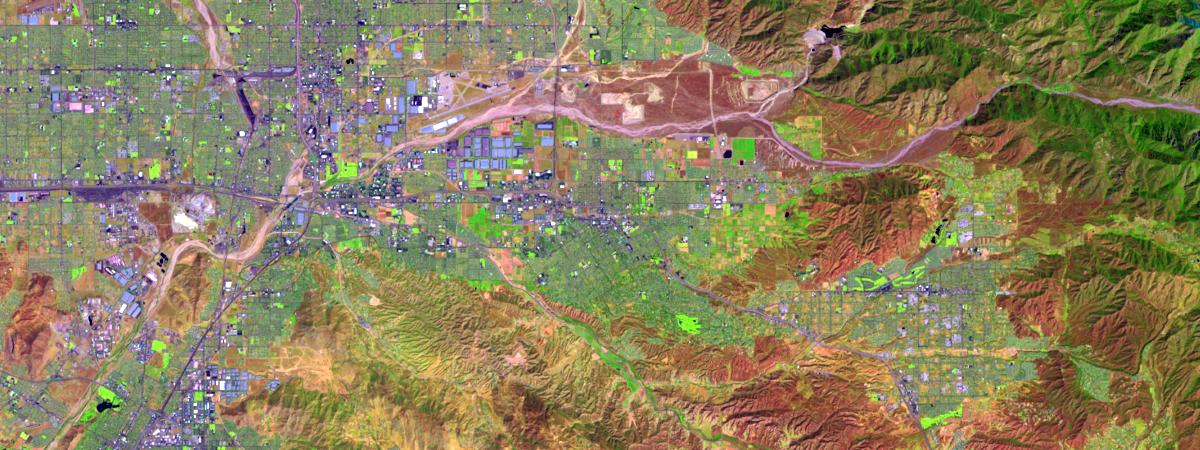

In [60]:
Image(selected.first().export_image(bbox=area['extent'], size=[1200,450], f='image'))

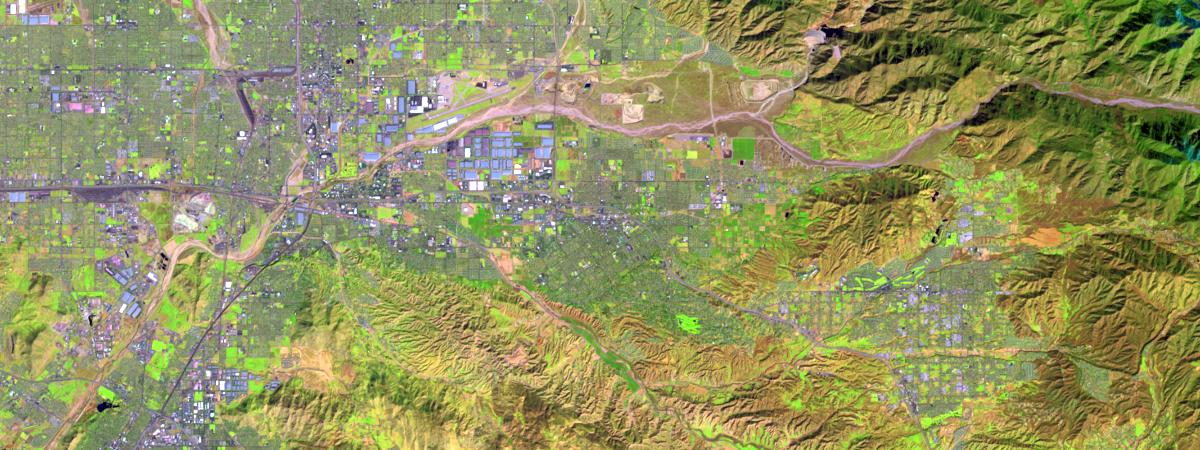

In [61]:
Image(selected.last().export_image(bbox=area['extent'], size=[1200,450], f='image'))

In [62]:
selected.properties

{
  "copyrightText": "",
  "pixelSizeX": 30,
  "allowedMosaicMethods": "ByAttribute,NorthWest,Center,LockRaster,Nadir,None",
  "supportsStatistics": true,
  "hasColormap": false,
  "maxImageHeight": 2000,
  "hasHistograms": false,
  "maxValues": [
    55000,
    55000,
    55000,
    55000,
    55000,
    55000,
    55000,
    55000
  ],
  "stdvValues": [
    3750,
    3750,
    3750,
    3750,
    3750,
    3750,
    3750,
    3750
  ],
  "initialExtent": {
    "xmax": 20037512.9328,
    "spatialReference": {
      "wkid": 102100,
      "latestWkid": 3857
    },
    "xmin": -20037507.0672,
    "ymin": -9694139.692100003,
    "ymax": 9698850.307899997
  },
  "maxImageWidth": 2000,
  "extent": {
    "xmax": 20037512.9328,
    "spatialReference": {
      "wkid": 102100,
      "latestWkid": 3857
    },
    "xmin": -20037507.0672,
    "ymin": -9694139.692100003,
    "ymax": 9698850.307899997
  },
  "objectIdField": "OBJECTID",
  "spatialReference": {
    "wkid": 102100,
    "latestWkid": 3

In [63]:
m.draw(fs)

# Temporal profile

In [64]:
values = landsat.get_samples(area['location'], return_first_value_only=False)

In [65]:
len(values)

20

In [66]:
values

[{'location': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
   'x': -13044700.296717701,
   'y': 4036265.730116022},
  'locationId': 0,
  'rasterId': 478593,
  'resolution': 30,
  'value': '12568 11971 11215 11257 13052 11427 10730 5087'},
 {'location': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
   'x': -13044700.296717701,
   'y': 4036265.730116022},
  'locationId': 0,
  'rasterId': 478594,
  'resolution': 30,
  'value': '12467 11872 11127 11163 12964 11374 10689 5087'},
 {'location': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
   'x': -13044700.296717701,
   'y': 4036265.730116022},
  'locationId': 0,
  'rasterId': 463490,
  'resolution': 30,
  'value': '12620 11804 10850 10347 11263 11774 10358 5045'},
 {'location': {'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
   'x': -13044700.296717701,
   'y': 4036265.730116022},
  'locationId': 0,
  'rasterId': 441267,
  'resolution': 30,
  'value': '13107 12325 10984 10442 11586 11184 10

# Change Detection

In [67]:
old = landsat.filter_by('OBJECTID=1139')

In [68]:
new = landsat.filter_by('OBJECTID=463490')

## Difference Image

Difference Image mode illustrates all the changes in the selected index between the two dates-increases are shown in green, and decreases are shown in magenta. 

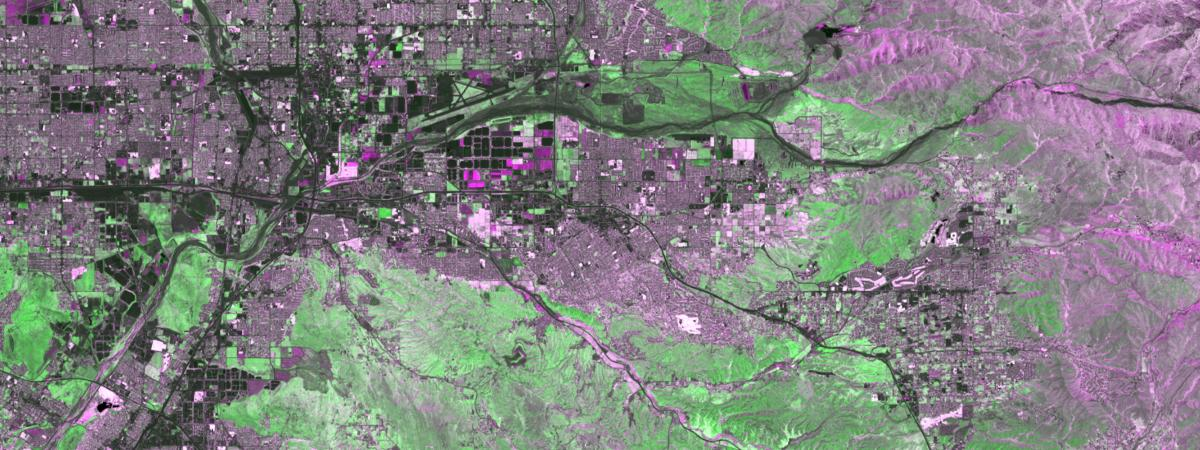

In [69]:
diff = stretch(composite_band([ndvi(old, '5 4'),
                               ndvi(new, '5 4'),
                               ndvi(old, '5 4')]), 
                               stretch_type='stddev',  num_stddev=3, min=0, max=255, dra=True, astype='u8')
Image(diff.export_image(bbox=area['extent'], size=[1200,450], f='image'))

In [70]:
ndvi_diff = ndvi(new, '5 4') - ndvi(old, '5 4')

In [71]:
ndvi_diff._fn

{'rasterFunction': 'Arithmetic',
 'rasterFunctionArguments': {'CellsizeType': 0,
  'ExtentType': 0,
  'OperationType': 2,
  'Raster': {'rasterFunction': 'BandArithmetic',
   'rasterFunctionArguments': {'BandIndexes': '5 4',
    'Method': 1,
    'Raster': '$463490'},
   'variableName': 'Raster'},
  'Raster2': {'rasterFunction': 'BandArithmetic',
   'rasterFunctionArguments': {'BandIndexes': '5 4',
    'Method': 1,
    'Raster': '$1139'},
   'variableName': 'Raster'}}}

In [72]:
threshold_val = 0.6

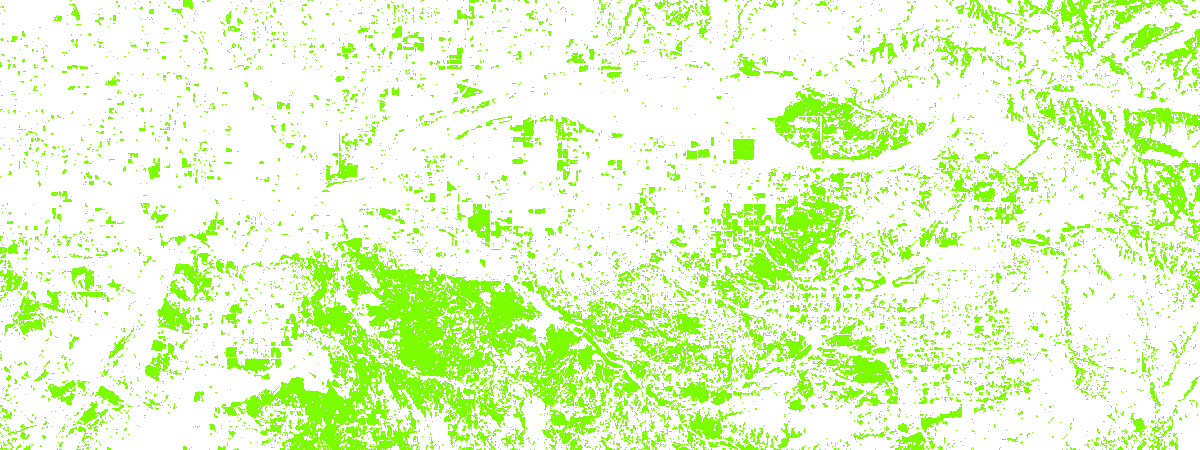

In [73]:
masked = colormap(remap(ndvi_diff, 
                        input_ranges=[threshold_val, 1], 
                        output_values=[1], 
                        no_data_ranges=[-1, threshold_val], astype='u8'), 
                  colormap=[[1, 124, 252, 0]], astype='u8')

Image(masked.export_image(bbox=area['extent'], size=[1200,450], f='image'))

## Add difference image as a layer to map widget

In [74]:
m = gis.map('Redlands, CA')

In [75]:
m

In [76]:
m.add_layer(diff)

In [77]:
m.add_layer(masked)

## Save as item in portal for visualization

In [78]:
lyr = masked.save('Test_viz_layer3', for_viz=True)

In [79]:
lyr

<Item title:"Test_viz_layer3" type:Image Service owner:rsingh_geosaurus>